# **Notebook Structure**

1. Title Page
2. Project Introduction
3. Import Required Libraries
4. Load the Dataset
5. Dataset Overview
6. Dataset Inspection
7. Data Cleaning
8. Exploratory Data Analysis (EDA)
9. Problem Framing
10. Feature Engineering & Encoding
11. Train-Test Split
12. Machine Learning Plan
13. Conclusion

# Customer Churn Prediction for ABC Communications Ltd

## AnalystLab Africa – Machine Learning Internship Programme

### Week 1: Machine Learning Problem Framing & Data Understanding

---

**Prepared by:** Christian Agyapong

**Programme:** Machine Learning Internship

**Project:** Customer Churn Prediction

**Dataset:** Telco Customer Churn Dataset (Blastchar)

**Problem Type:** Binary Classification

---

## Project Objectives

- Understand the business problem.
- Inspect the dataset.
- Identify data quality issues.
- Perform exploratory data analysis.
- Prepare the dataset for machine learning.
- Recommend suitable machine learning algorithms.

# 1. Project Introduction

Customer churn is one of the most significant challenges facing telecommunication companies. Customers who cancel their subscriptions reduce company revenue and increase customer acquisition costs.

ABC Communications Ltd intends to leverage Machine Learning to predict customer churn before customers leave. By identifying customers who are likely to churn, the company can implement proactive retention strategies such as promotional offers, personalized customer support, and loyalty rewards.

This notebook documents the first phase of the Customer Churn Prediction project, focusing on business understanding, dataset inspection, data preprocessing, exploratory data analysis, and preparation for machine learning model development.

In [11]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load the Dataset

The Telco Customer Churn dataset is loaded into a Pandas DataFrame for inspection and analysis.

The dataset contains customer demographic information, subscribed services, billing details, and customer churn status.

In [19]:
# ============================================================
# Load Dataset
# ============================================================

import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print(" Dataset loaded successfully!")

 Dataset loaded successfully!


# 3. Dataset Preview

The first and last five records provide an initial understanding of the dataset structure and available variables.

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


# 4. Dataset Dimensions

Understanding the dimensions of the dataset helps determine the number of customer records and available features for analysis.

In [17]:
rows, columns = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Rows    : 7043
Columns : 21


### Observation

The dataset contains **7,043 customer records** and **21 variables**.

Each row represents one customer, while each column contains demographic, service, account, billing, or churn information.

# 5. Dataset Information

The `info()` function provides an overview of each column, including the data type and the number of non-null values.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

The dataset consists of both numerical and categorical variables.

Most categorical variables are stored as the **object** data type.

The **TotalCharges** column is also stored as an object even though it should contain numerical values. This suggests that the column may contain blank strings or other non-numeric values that will require cleaning.

# 6. Feature Names

The following code displays all variables contained in the dataset.

In [20]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

# 7. Summary Statistics

Summary statistics provide useful information about the numerical variables in the dataset.

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observation

The summary statistics show that customer tenure ranges from newly joined customers to long-term subscribers.

Monthly charges vary considerably across customers, suggesting different subscription plans and service packages.

These numerical variables may play an important role in predicting customer churn.

# 8. Missing Values

Before developing a machine learning model, it is important to identify missing values that could affect model performance.

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Observation

The dataset does not contain standard `NaN` values.

However, the **TotalCharges** column may contain blank strings that should be treated as missing values.

In [23]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Observation

The inspection confirms that the **TotalCharges** column contains blank entries.

These blank strings must be replaced with `NaN` before converting the column to a numeric data type.

# 9. Duplicate Records

Duplicate customer records can negatively affect machine learning models by introducing bias.

The following code checks whether duplicate records exist.

In [24]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate customer records were found in the dataset.

Each customer appears only once, indicating that duplicate removal is not required.

# 10. Data Cleaning

The `TotalCharges` column contains blank strings that must be converted into missing values before being transformed into a numerical variable.

In [25]:
# Replace blank strings with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Fill missing values with the median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

The `TotalCharges` feature has been successfully converted into a numerical variable, and missing values have been handled using median imputation.

The dataset is now cleaner and more suitable for exploratory data analysis and machine learning.

# 11. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of customer characteristics, identify important patterns, and discover relationships between variables before developing machine learning models.

The objectives of this analysis are to:

- Explore the distribution of customer attributes.
- Compare customer groups.
- Identify variables that influence customer churn.
- Visualize numerical feature distributions.
- Examine correlations among variables.

## 11.1 Customer Churn Distribution

This chart shows the number of customers who stayed with the company versus those who left (churned).

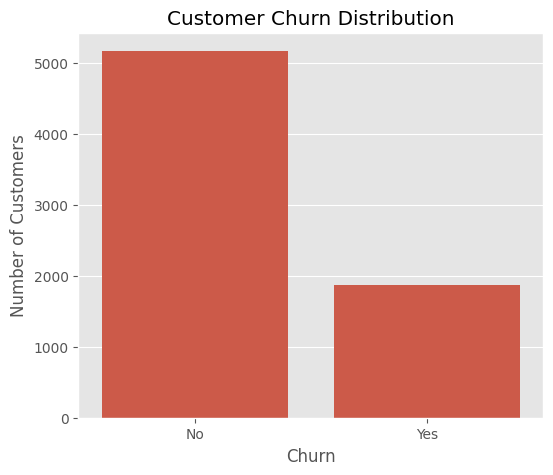

In [27]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Most customers remained with the company, while a smaller proportion churned.

This indicates that the dataset is **slightly imbalanced**, meaning there are more non-churning customers than churning customers. During model development, this imbalance should be considered when selecting evaluation metrics and algorithms.

## 11.2 Churn by Contract Type

Contract type may influence customer loyalty. This chart compares churn across different contract types.

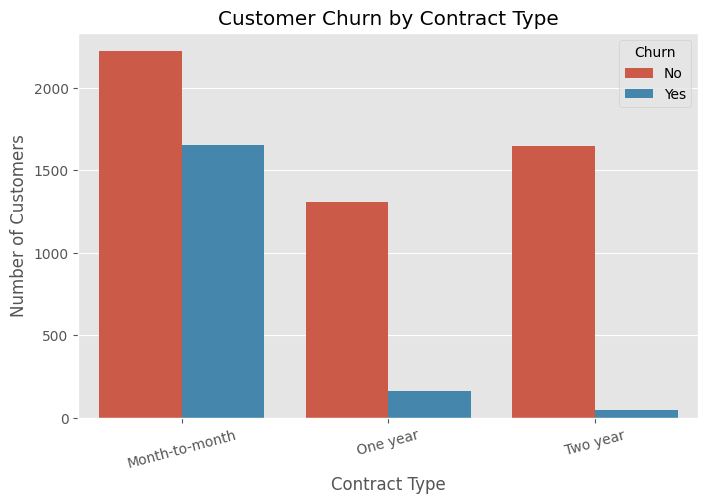

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Observation

Customers with **month-to-month contracts** experience noticeably higher churn than those with one-year or two-year contracts.

This suggests that longer contract commitments are associated with higher customer retention and may be an important predictor in the machine learning model.

## 11.3 Churn by Internet Service

This visualization compares customer churn across different internet service types.

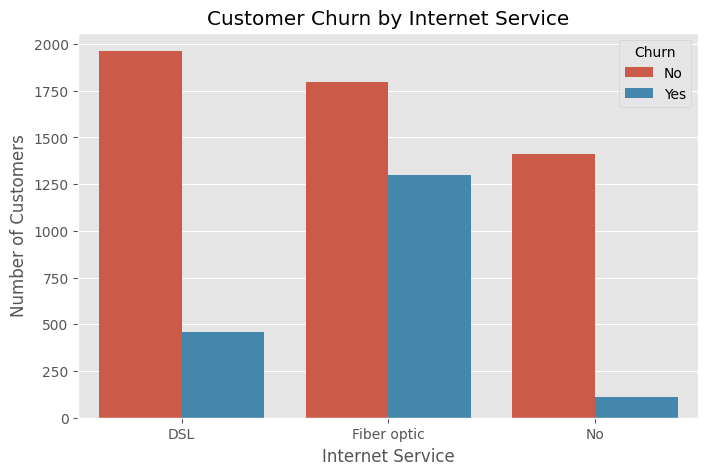

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart indicates that churn varies across internet service types. Customers using fibre optic services tend to exhibit higher churn than customers using DSL or those without internet service.

This suggests that the type of internet service may influence customer satisfaction and should be included as an important predictive feature.

## 11.4 Distribution of Customer Tenure

This histogram shows how long customers have remained with the company.

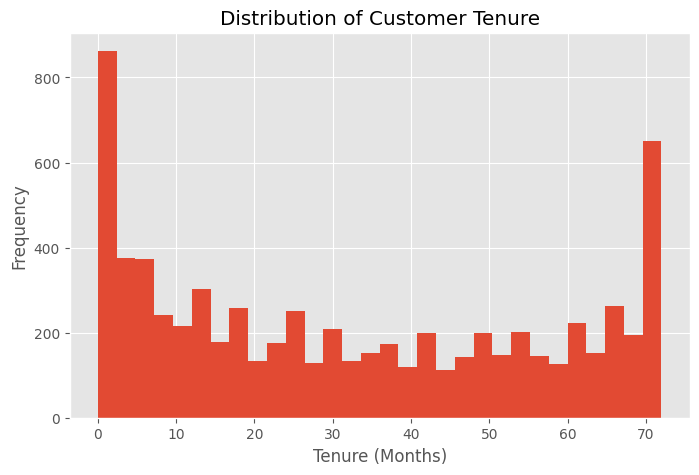

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution indicates that many customers are relatively new, while another large group has remained with the company for an extended period.

This suggests that customer tenure may be a strong indicator of churn, as newer customers are often more likely to leave than long-term subscribers.

## 11.5 Distribution of Monthly Charges

This histogram displays the distribution of monthly subscription charges across customers.

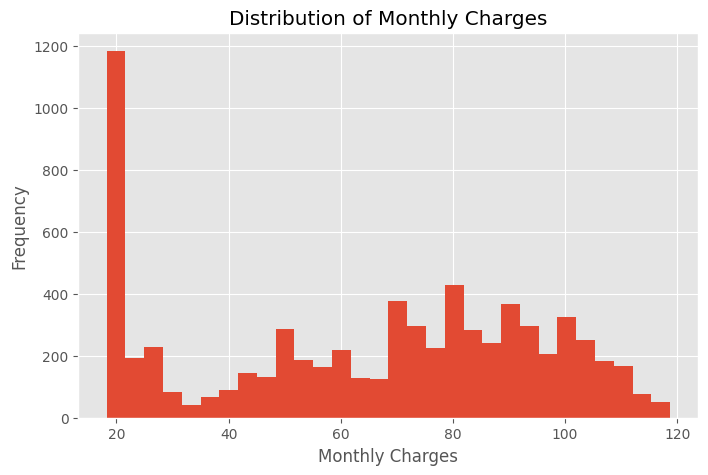

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

### Observation

Monthly charges vary across customers, reflecting different service packages and pricing plans.

Customers with higher monthly charges may be more likely to churn if they perceive insufficient value for the services received. This feature should therefore be considered during model development.

## 11.6 Correlation Heatmap

Correlation analysis helps identify relationships between variables and provides insight into which features may influence customer churn.

Categorical variables are encoded temporarily for visualization purposes.

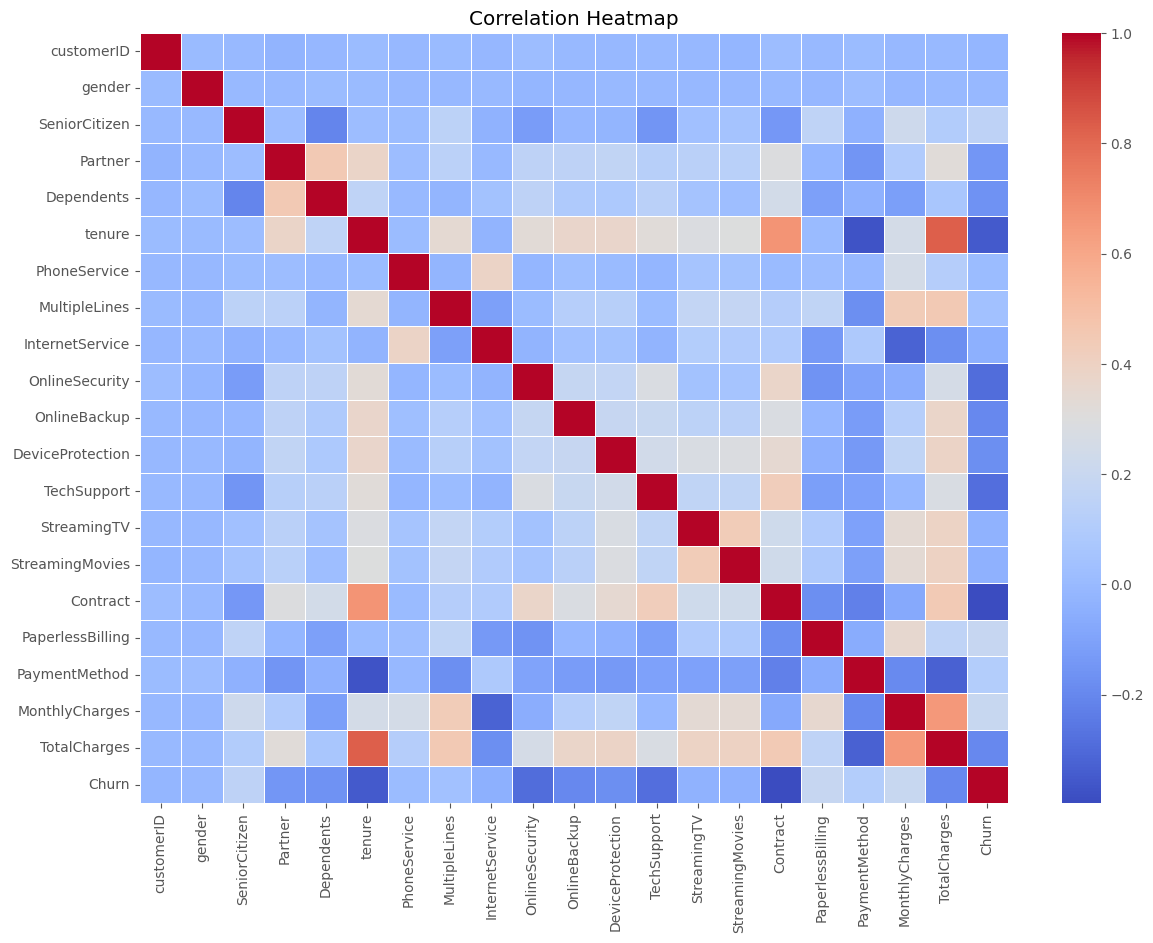

In [32]:
# Create a copy of the dataset
encoded_df = df.copy()

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in encoded_df.columns:
    if encoded_df[column].dtype == "object":
        encoded_df[column] = encoder.fit_transform(encoded_df[column])

# Compute correlation matrix
correlation_matrix = encoded_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows that no single feature has an extremely strong relationship with customer churn. Instead, churn is influenced by a combination of customer demographics, service subscriptions, contract details, and billing information.

Features such as **Contract**, **tenure**, **MonthlyCharges**, and **TotalCharges** exhibit meaningful relationships with churn and are expected to contribute significantly to predictive performance.

# 12. Problem Framing

Problem framing is the process of translating a business challenge into a machine learning problem.

For ABC Communications Ltd, the objective is to identify customers who are likely to discontinue their services before they actually leave the company.

By accurately predicting customer churn, the company can implement proactive customer retention strategies such as personalized offers, improved customer support, and loyalty incentives.

This section identifies the target variable, input features, and preprocessing requirements needed before building machine learning models.

## 12.1 Target Variable

The target variable is the variable that the machine learning model is expected to predict.

For this project, the target variable is:

**Churn**

Possible values:

- Yes → Customer left the company
- No → Customer remained with the company

Since there are only two possible outcomes, this is a **Binary Classification** problem.

In [33]:
# Display the target variable distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Observation

The target variable contains two classes:

- **Yes** – Customers who churned.
- **No** – Customers who remained with the company.

The machine learning model will learn patterns from historical customer data to predict these two outcomes.

## 12.2 Input Features

Input features are the variables used by the machine learning model to make predictions.

The dataset contains customer demographic information, subscribed services, contract details, billing information, and account history.

The **customerID** column is excluded because it uniquely identifies customers and does not contribute useful information for prediction.

In [34]:
# Display all available features
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [35]:
# Create a list of input features (excluding customerID and Churn)
input_features = df.drop(columns=["customerID", "Churn"]).columns

print("Input Features:\n")

for feature in input_features:
    print(feature)

Input Features:

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges


### Observation

The input features include demographic information, service subscriptions, contract details, and billing information.

These variables provide valuable information that enables the machine learning model to identify customers who are likely to churn.

## 12.3 Machine Learning Problem Type

Machine learning problems generally fall into two categories:

- Classification
- Regression

Because the objective is to predict whether a customer will **churn ("Yes") or not churn ("No")**, this project is classified as a **Binary Classification** problem.

Regression algorithms are not appropriate because the target variable is categorical rather than continuous.

In [36]:
print("Problem Type: Binary Classification")

Problem Type: Binary Classification


### Observation

The machine learning model will classify customers into one of two categories:

- Churn
- No Churn

This makes classification algorithms such as Logistic Regression, Decision Trees, Random Forest, Support Vector Machine (SVM), and XGBoost appropriate choices for this project.

## 12.4 Preprocessing Requirements

Before training a machine learning model, the dataset must be prepared to improve data quality and ensure compatibility with machine learning algorithms.

The following preprocessing steps are required.

In [37]:
preprocessing_steps = [
    "Remove customerID column",
    "Handle missing values",
    "Convert TotalCharges to numeric",
    "Encode categorical variables",
    "Scale numerical features where required",
    "Separate features (X) and target (y)",
    "Split the dataset into training and testing sets"
]

for i, step in enumerate(preprocessing_steps, start=1):
    print(f"{i}. {step}")

1. Remove customerID column
2. Handle missing values
3. Convert TotalCharges to numeric
4. Encode categorical variables
5. Scale numerical features where required
6. Separate features (X) and target (y)
7. Split the dataset into training and testing sets


### Observation

The preprocessing plan ensures that the dataset is clean, consistent, and ready for machine learning.

Proper preprocessing improves model performance, reduces errors during training, and ensures that all features are in a format suitable for predictive modelling.

## 12.5 Recommended Machine Learning Algorithms

Several supervised learning algorithms are suitable for predicting customer churn.

Recommended algorithms include:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost
- LightGBM

These algorithms will be evaluated in future stages of the project using multiple performance metrics to determine the most effective model.

In [38]:
algorithms = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Support Vector Machine (SVM)",
    "XGBoost",
    "LightGBM"
]

for algorithm in algorithms:
    print("•", algorithm)

• Logistic Regression
• Decision Tree
• Random Forest
• Support Vector Machine (SVM)
• XGBoost
• LightGBM


# 12.6 Problem Framing Summary

The customer churn prediction project has been successfully framed as a supervised binary classification problem.

The target variable (**Churn**) and the relevant input features have been identified. In addition, the preprocessing requirements and suitable machine learning algorithms have been outlined.

With the business problem clearly defined and the dataset understood, the project is now ready for feature engineering, data preprocessing, and preparation for model training.

# 13. Feature Engineering & Data Preprocessing

Machine learning algorithms require numerical input data. Therefore, the dataset must undergo preprocessing before model development.

The preprocessing steps performed in this section include:

- Removing unnecessary columns.
- Separating input features and the target variable.
- Encoding categorical variables.
- Preparing the dataset for model training.

These steps improve data quality and ensure compatibility with machine learning algorithms.

## 13.1 Remove Customer Identifier

The **customerID** column uniquely identifies each customer.

Since it does not contribute useful information for predicting customer churn, it is removed before model training.

In [39]:
# Remove customerID

df = df.drop("customerID", axis=1)

print("customerID column removed successfully.")

customerID column removed successfully.


In [40]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observation

The customer identifier has been removed successfully.

Removing identifier columns prevents the model from learning meaningless patterns that do not contribute to prediction.

## 13.2 Separate Features and Target Variable

The dataset is divided into:

- **X** → Input Features
- **y** → Target Variable (Churn)

This separation is required before training any supervised machine learning model.

In [41]:
# Input Features

X = df.drop("Churn", axis=1)

# Target Variable

y = df["Churn"]

print("Features and target created successfully.")

Features and target created successfully.


In [42]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


### Observation

The dataset has been successfully divided into input features (**X**) and the target variable (**y**).

The feature matrix contains 19 predictor variables, while the target variable contains the customer churn labels.

## 13.3 Encode the Target Variable

Machine learning algorithms require numerical values.

The target variable **Churn** is therefore encoded as:

- No → 0
- Yes → 1

In [43]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Target variable encoded successfully.")

Target variable encoded successfully.


In [44]:
print(y[:10])

[0 0 1 0 1 1 0 0 1 0]


### Observation

The target variable has been converted into binary numerical values suitable for machine learning algorithms.

## 13.4 Encode Categorical Features

Most variables in the dataset are categorical.

These variables are converted into numerical representations using **One-Hot Encoding**.

One-Hot Encoding prevents machine learning algorithms from assuming an incorrect numerical relationship between categories.

In [45]:
X = pd.get_dummies(X, drop_first=True)

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [46]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


### Observation

All categorical variables have been transformed into numerical features.

The dataset is now compatible with machine learning algorithms that require numerical input.

## 13.5 Verify Processed Dataset

The processed dataset is inspected to confirm that encoding was successful.

In [47]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (7043, 30)
Target Shape : (7043,)


### Observation

The feature matrix now contains a larger number of variables because categorical features have been expanded through One-Hot Encoding.

This transformation allows machine learning algorithms to utilize categorical information effectively.

In [48]:
X.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

### Observation

All predictor variables are now numerical, confirming that the dataset is ready for machine learning.

# 13.6 Feature Engineering Summary

The preprocessing stage has successfully prepared the dataset for machine learning.

The following tasks were completed:

- Removed unnecessary identifier columns.
- Separated input features and the target variable.
- Encoded the target variable.
- Converted categorical variables using One-Hot Encoding.
- Verified the processed dataset.

The data is now ready for splitting into training and testing datasets before model development.

# 14. Train-Test Split

Before training a machine learning model, the dataset must be divided into two subsets:

- **Training Set** – Used to train the machine learning model.
- **Testing Set** – Used to evaluate the model's performance on unseen data.

For this project, an **80:20 split** is used, meaning 80% of the data is used for training and 20% is reserved for testing.

In [49]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

Train-test split completed successfully.


## Verify the Dataset Sizes

The following code confirms the number of samples in the training and testing datasets.

In [50]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 30)
Testing Features  : (1409, 30)

Training Labels   : (5634,)
Testing Labels    : (1409,)


### Observation

The dataset has been successfully divided into training and testing sets.

Using an 80:20 split ensures that the machine learning model is trained on sufficient historical data while reserving unseen data for an unbiased evaluation of model performance.

The `stratify=y` parameter preserves the original distribution of churn and non-churn classes in both datasets, which is especially important for classification problems.

# 15. Machine Learning Plan

With the dataset prepared, the next stage of the project will involve developing and evaluating multiple supervised machine learning models.

The objective is to identify the model that provides the highest predictive performance for customer churn prediction.

## Recommended Machine Learning Algorithms

The following algorithms are recommended for this project:

| Algorithm | Purpose |
|-----------|---------|
| Logistic Regression | Baseline classification model |
| Decision Tree | Rule-based classification |
| Random Forest | Ensemble learning with improved accuracy |
| Support Vector Machine (SVM) | High-dimensional classification |
| XGBoost | Gradient boosting for high performance |
| LightGBM | Fast and scalable boosting algorithm |

Each algorithm will be trained and evaluated in a future stage of the project.

## Model Evaluation Metrics

The following evaluation metrics will be used to compare model performance:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

Using multiple metrics provides a comprehensive evaluation of each model's predictive capability, particularly because customer churn datasets may exhibit class imbalance.

## Expected Outcome

The final machine learning model should:

- Accurately identify customers likely to churn.
- Reduce customer attrition.
- Support proactive customer retention strategies.
- Improve data-driven decision-making.
- Enhance customer satisfaction and long-term profitability.

# 16. Conclusion

This notebook presented the first phase of the Customer Churn Prediction project for ABC Communications Ltd.

The work completed includes:

- Business understanding and problem definition.
- Dataset loading and inspection.
- Data cleaning and preprocessing.
- Exploratory Data Analysis (EDA).
- Problem framing.
- Feature engineering and encoding.
- Train-test split preparation.
- Machine learning planning.

The exploratory analysis revealed that customer churn is influenced by multiple factors, including contract type, tenure, internet service, and monthly charges.

The dataset has been successfully prepared for machine learning model development.

In the next phase of the project, predictive models will be trained, evaluated, and compared to identify the most effective algorithm for predicting customer churn.